<a href="https://colab.research.google.com/github/leejungp2/dl-study/blob/main/260308_03_pytorch_computer_vision_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Computer Vision

* See reference notebook - https://github.com/mrdbourke/pytorch-deep-learning/blob/main/03_pytorch_computer_vision.ipynb
* See reference online book - https://www.learnpytorch.io/03_pytorch_computer_vision/

## 0. PyTorch의 컴퓨터 비전 라이브러리 Computer vision libaries in PyTorch

* [`torchvision`](https://www.learnpytorch.io/03_pytorch_computer_vision/): PyTorch 컴퓨터 비전의 핵심 도메인 라이브러리
*   **`torchvision.datasets`**: 다양한 컴퓨터 비전 데이터셋과 데이터 로딩 함수 제공
    - MNIST, CIFAR-10과 같은 유명한 벤치마크 데이터셋 내려받을 수 있는 기능 제공
*   **`torchvision.models`**: 실제 문제 해결에 즉시 활용 가능한 사전 학습된(Pretrained) 모델 제공
*   **`torchvision.transforms`**: 이미지 데이터를 모델 입력에 적합하게 변환(전처리)하는 함수 모음
*   **`torch.utils.data.Dataset`**: PyTorch 데이터셋 구성을 위한 기본 추상 클래스
*   **`torch.utils.data.DataLoader`**: 데이터셋을 배치(Batch) 단위로 반환하는 파이썬 반복자(Iterable) 생성

In [ ]:
# Import PyTorch
import torch
from torch import nn ## 산경망 구성을 위한 계층(Layer), 손실 함수(Loss function) 등이 포함된 모듈

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


## 1. Getting a dataset

The dataset we'll be using is FashionMNIST from torchvision.datasets - https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html#torchvision.datasets.FashionMNIST

In [ ]:
# Setup training data
from torchvision import datasets
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # do we want the training dataset?
    download=True, # do we want to download yes/no?
    transform=torchvision.transforms.ToTensor(), # how do we want to transform the data?
    target_transform=None # how do we want to transform the labels/targets?
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [ ]:
len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [ ]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [ ]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

### 1.1 Check input and output shapes of data

In [ ]:
# Check the shape of our image
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label: {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot


### 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


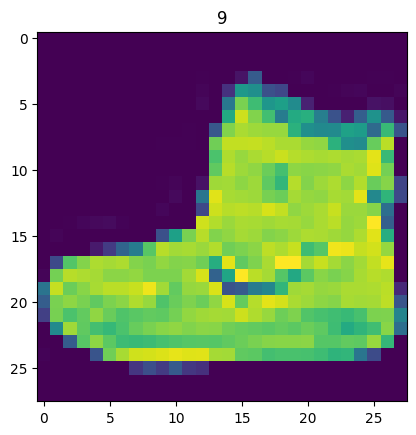

In [ ]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label);
# image

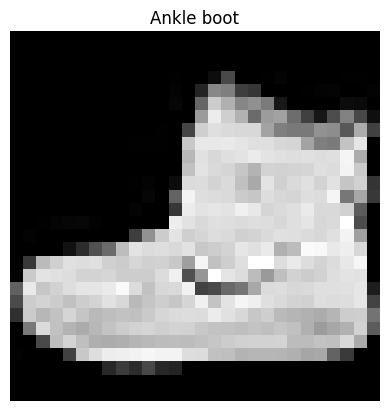

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);
plt.axis(False);

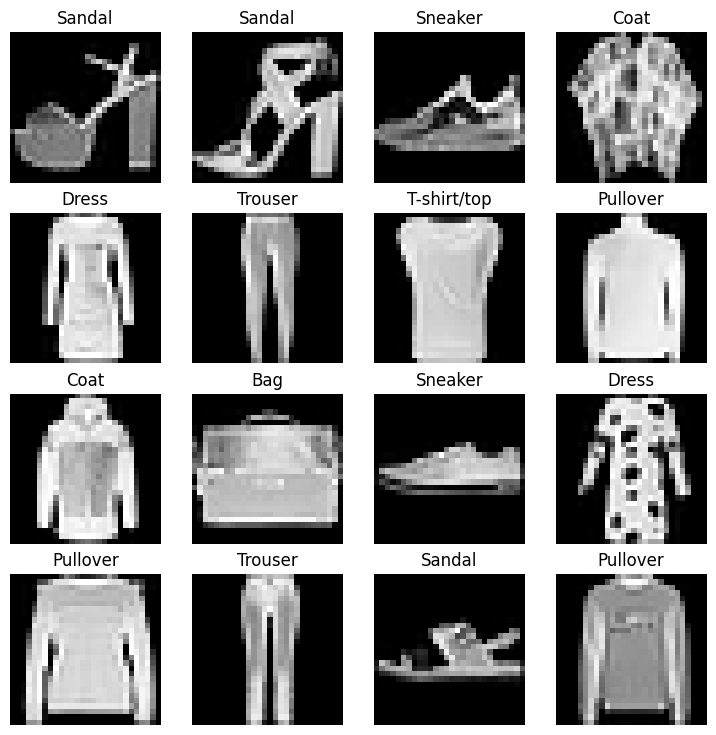

In [ ]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows*cols+1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  img, label = train_data[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img.squeeze(), cmap="gray")
  plt.title(class_names[label])
  plt.axis(False);

Do you think these items of clothing (images) could be modelled with pure linear lines? Or do you think we'll need non-linearities?

In [ ]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader

Right now, our data is in the form of PyTorch Datasets.

DataLoader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batches (or mini-batches).

Why would we do this?

1. It is more computationally efficient, as in, your computing hardware may not be able to look (store in memory) at 60000 images in one hit. So we break it down to 32 images at a time (batch size of 32).
2. It gives our neural network more chances to update its gradients per epoch.

For more on mini-batches, see here: https://youtu.be/l4lSUAcvHFs

In [ ]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7dee3f663c50>,
 <torch.utils.data.dataloader.DataLoader at 0x7dee3f662ba0>)

In [ ]:
# Let's check out what what we've created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7dee3f663c50>, <torch.utils.data.dataloader.DataLoader object at 0x7dee3f662ba0>)
Length of train_dataloader: 1875 batches of 32...
Length of test_dataloader: 313 batches of 32...


In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size: torch.Size([1, 28, 28])
Label: 5, label size: torch.Size([])


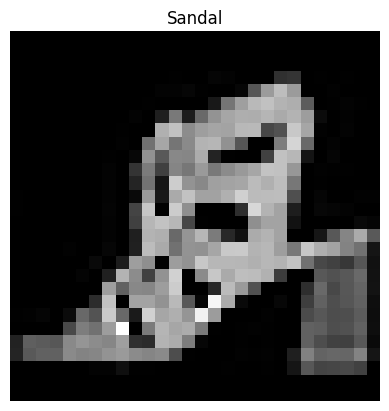

In [ ]:
# Show a sample
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")

## 3. Model 0: Build a basline model

When starting to build a series of machine learning modelling experiments, it's best practice to start with a baseline model.

A baseline model is a simple model you will try and improve upon with subsequent models/experiments.

In other words: start simply and add complexity when necessary.

In [ ]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = train_features_batch[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


In [ ]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

In [ ]:
torch.manual_seed(42)

# Setup model with input parameters
model_0 = FashionMNISTModelV0(
    input_shape=28*28, # this is 28*28
    hidden_units=10, # how mnay units in the hidden layer
    output_shape=len(class_names) # one for every class
).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [ ]:
dummy_x = torch.rand([1, 1, 28, 28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss function - since we're working with multi-class data, our loss function will be `nn.CrossEntropyLoss()`
* Optimizer - our optimizer `torch.optim.SGD()` (stochastic gradient descent)
* Evaluation metric - since we're working on a classification problem, let's use accruacy as our evaluation metric

In [ ]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download...")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

helper_functions.py already exists, skipping download...


In [ ]:
# Import accuracy metric
from helper_functions import accuracy_fn

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

### 3.2 Creating a function to time our experiments

Machine learning is very experimental.

Two of the main things you'll often want to track are:
1. Model's performance (loss and accuracy values etc)
2. How fast it runs

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float,
                     end: float,
                     device: torch.device = None):
  """Prints difference between start and end time."""
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [ ]:
start_time = timer()
# some code...
end_time = timer()
print_train_time(start=start_time, end=end_time, device="cpu")

Train time on cpu: 0.000 seconds


4.628099986803136e-05

### 3.3 Creating a training loop and training a model on batches of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*.
4. Print out what's happening.
5. Time it all (for fun).

**Note:** Because we are computing on *batches*, the optimizer will update the model's parameters once *per batch* rather than once per epoch.

In [ ]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training time)
epochs = 3

# Create training and test loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  ### Training
  train_loss = 0
  # Add a loop to loop through the training batches
  for batch, (X, y) in enumerate(train_dataloader):
    model_0.train()
    # 1. Forward pass
    y_pred = model_0(X)

    # 2. Calculate loss (per batch)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate train loss

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Optimizer step (update the model's parameters once *per batch*)
    optimizer.step()

    # Print out what's happening
    if batch % 400 == 0:
        print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader)

  ### Testing
  test_loss, test_acc = 0, 0
  model_0.eval()
  with torch.inference_mode():
    for X_test, y_test in test_dataloader:
      # 1. Forward pass
      test_pred = model_0(X_test)

      # 2. Calculate loss (accumulatively)
      test_loss += loss_fn(test_pred, y_test)

      # 3. Calculate accuracy
      test_acc += accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))

    # Calculate the test loss average per batch
    test_loss /= len(test_dataloader)

    # Calculate the test acc average per batch
    test_acc /= len(test_dataloader)

  # Print out what's happening
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.5904 | Test loss: 0.5095, Test acc: 82.0387
Epoch: 1
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4763 | Test loss: 0.4799, Test acc: 83.1969
Epoch: 2
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4550 | Test loss: 0.4766, Test acc: 83.4265
Train time on cpu: 27.931 seconds


## 4. Make predictions and get Model 0 results

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))

    # Scale loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with a class
          "model_loss": loss.item(),
          "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

## 5. Setup device agnostic-code (for using a GPU if there is one)




In [ ]:
!nvidia-smi

Sun Mar 22 10:46:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             15W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
torch.cuda.is_available()

True

In [ ]:
# Setup device-agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. Model 1: Building a better model with non-linearity

We learned about the power of non-linearity in notebook 02 - https://www.learnpytorch.io/02_pytorch_classification/#6-the-missing-piece-non-linearity

In [ ]:
# 비선형 레이어(ReLU)와 선형 레이어(Linear)를 조합한 모델 생성
class FashionMNISTModelV1(nn.Module):
  def __init__(self,
               input_shape: int,    # 입력 특징 수 (예: 28*28=784)
               hidden_units: int,   # 은닉층의 뉴런 수
               output_shape: int):  # 출력 클래스 수 (예: 10개)
    super().__init__()
    # nn.Sequential을 사용하여 레이어를 순서대로 쌓음
    self.layer_stack = nn.Sequential(
        # 1. Flatten: 28x28 이미지 행렬을 784개의 1차원 벡터로 쭉 폅니다.
        nn.Flatten(),

        # 2. Linear: 첫 번째 선형 레이어 (입력 -> 은닉층)
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),

        # 3. ReLU: 비선형 활성화 함수. 모델이 복잡한 패턴을 배울 수 있게 해줍니다.
        nn.ReLU(),

        # 4. Linear: 두 번째 선형 레이어 (은닉층 -> 출력)
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape),

        # 5. ReLU: 출력층 뒤에 추가된 비선형성 (상황에 따라 생략하기도 함)
        nn.ReLU()
    )

  def forward(self, x: torch.Tensor):
    # 입력 데이터 x를 위에서 정의한 layer_stack에 통과시킵니다.
    return self.layer_stack(x)

In [ ]:
# 모델 인스턴스 생성 및 설정
torch.manual_seed(42) # 결과 재현을 위한 시드 고정
model_1 = FashionMNISTModelV1(input_shape=784, # 28*28 이미지의 픽셀 수
                              hidden_units=10, # 은닉층 뉴런 10개
                              output_shape=len(class_names) # 클래스 개수(10개)
                              ).to(device) # 모델을 설정된 장치(CPU/GPU)로 보냄

# 모델의 첫 번째 파라미터가 어느 장치(CPU/GPU)에 있는지 확인
next(model_1.parameters()).device

device(type='cuda', index=0)

### 6.1 Setup loss, optimizer and evaluation metrics
> 손실 함수, 최적화 도구 및 평가 지표 설정
- Loss (손실 함수): 모델의 예측값과 실제값의 차이를 계산하여 모델이 얼마나 '틀렸는지' 수치화합니다.
- Optimizer (최적화 도구): 손실 함수를 줄이기 위해 모델의 가중치(Weights)를 어떻게 업데이트할지 결정하는 알고리즘입니다.
- Evaluation metrics (평가 지표): 정확도(Accuracy) 등 훈련 과정이나 테스트 시 모델의 성능을 측정하는 기준입니다.

In [ ]:
from helper_functions import accuracy_fn ## 정확도 계산 함수
loss_fn = nn.CrossEntropyLoss() ## 손실함수 정의, 주로 다중 분류(Multi-class Classification) 문제에서 사용
optimizer = torch.optim.SGD(params=model_1.parameters(), ## 최적화 도구로 SGD(Stochastic Gradient Descent, 확률적 경사 하강법) 사용
                            lr=0.1)
## model_1이 가진 가중치(Weights)와 편향(Bias)들을 업데이트 대상으로 지정, 학습률 0.1

### 6.2 Functionizing training and evaluation/testing loops
> 훈련 및 평가/테스트 루프의 함수화

Let's create a function for:
* training loop - `train_step()`
* testing loop - `test_step()`

In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device): ## 필수는 X
  """Performs a training with model trying to learn on data_loader."""
  train_loss, train_acc = 0, 0

  # 모델을 훈련 모드로 설정 (드롭아웃, 배치 정규화 등 활성화)
  model.train()

  # Add a loop to loop through the training batches
  for batch, (X, y) in enumerate(data_loader): ## 배치 단위(X: 이미지, y: 레이블)로 꺼내어 반복
    # 데이터를 설정된 장치(CPU 또는 GPU)로 이동
    X, y = X.to(device), y.to(device)

    # 1. 순전파 (Forward pass): 모델에 데이터를 넣어 예측값(Logits) 계산
    y_pred = model(X)

    # 2. 손실 및 정확도 계산 (배치 단위)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate train loss
    ## 정확도 계산: logit 값 중 가장 높은 인덱스를 뽑아 실제 정답(y)과 비교
    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1)) # go from logits -> prediction labels

    # 3. 옵티마이저 기울기 초기화: 이전 배치의 기울기 값이 남지 않도록 0으로 비움
    optimizer.zero_grad()

    # 4. 역전파 (Loss backward): 손실을 바탕으로 각 파라미터의 기울기(Gradient) 계산
    loss.backward()

    # 5. 가중치 업데이트 (Optimizer step): 계산된 기울기를 바탕으로 모델 파라미터 수정
    optimizer.step()

  # 전체 손실과 정확도를 배치 개수로 나누어 평균값 계산
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

In [ ]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  """Performs a testing loop step on model going over data_loader."""
  test_loss, test_acc = 0, 0

  # Put the model in eval mode
  model.eval()

  # Turn on inference mode context manager
  with torch.inference_mode():
    for X, y in data_loader:
      # Send the data to the target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass (outputs raw logits)
      test_pred = model(X)

      # 2. Calculuate the loss/acc
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y,
                              y_pred=test_pred.argmax(dim=1)) # go from logits -> prediction labels

    # Adjust metrics and print out
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n")

In [ ]:
torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_on_gpu = timer()

# Set epochs 전체 데이터를 몇 번 반복해서 학습할지 설정
epochs = 3

# # train_step()과 test_step()을 사용하여 최적화 및 평가 루프 생성
## tqdm은 진행 상태를 시각화
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n----------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                            end=train_time_end_on_gpu,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
----------
Train loss: 1.09199 | Train acc: 61.34%
Test loss: 0.95636 | Test acc: 65.00%

Epoch: 1
----------
Train loss: 0.78101 | Train acc: 71.93%
Test loss: 0.72227 | Test acc: 73.91%

Epoch: 2
----------
Train loss: 0.67027 | Train acc: 75.94%
Test loss: 0.68500 | Test acc: 75.02%

Train time on cuda: 34.653 seconds


Note: 데이터나 하드웨어 환경에 따라, GPU보다 CPU에서 모델 학습 속도가 더 빠른 경우가 종종 발생할 수 있습니다.

왜 그럴까요?

1. 데이터 전송 오버헤드: 데이터를 GPU로 복사하거나 모델을 다시 가져오는 과정에서 발생하는 오버헤드가 GPU가 제공하는 연산상의 이점보다 더 클 수 있기 때문입니다.

2. 하드웨어 성능 차이: 사용 중인 시스템의 CPU 연산 능력이 상대적으로 GPU보다 더 뛰어난 사양일 수 있습니다.

- 모델의 연산 속도를 높이는 더 자세한 방법은 다음 링크를 확인하세요: https://horace.io/brrr_intro.html

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

In [ ]:
# Train time on CPU
total_train_time_model_0

27.931088188000103

In [ ]:
!nvidia-smi

Sun Mar 22 10:46:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P0             29W /   70W |     161MiB /  15360MiB |      3%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Get model_1 results dictionary
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device=device):
  """Returns a dictionary containing the results of model predicting on data_loader."""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      ## Make our data device agnostic
      X, y = X.to(device), y.to(device)

      # Make predictions
      y_pred = model(X)

      # Accumulate the loss and acc values per batch
      loss += loss_fn(y_pred, y)
      acc += accuracy_fn(y_true=y,
                         y_pred=y_pred.argmax(dim=1))

    # Scale loss and acc to find the average loss/acc per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with a class
          "model_loss": loss.item(),
          "model_acc": acc}

# Calculate model 0 results on test dataset
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [ ]:
# Get model_1 results dictionary
model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_1_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV1',
 'model_loss': 0.6850008964538574,
 'model_acc': 75.01996805111821}

In [ ]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663888335227966,
 'model_acc': 83.42651757188499}

## Model 2: Building a Convolutional Neural Network (CNN)

CNN's are also known ConvNets.

CNN's are known for their capabilities to find patterns in visual data.

To find out what's happening inside a CNN, see this website: https://poloclub.github.io/cnn-explainer/

In [ ]:
# Create a convolutional neural network
class FashionMNISTModelV2(nn.Module):
  """
  Model architecture that replicates the TinyVGG
  model from CNN explainer website.
  """
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        # Create a conv layer - https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # values we can set ourselves in our NN's are called hyperparameters
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, # there's a trick to calculating this...
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_block_1(x)
    # print(f"Output shape of conv_block_1: {x.shape}")
    x = self.conv_block_2(x)
    # print(f"Output shape of conv_block_2: {x.shape}")
    x = self.classifier(x)
    # print(f"Output shape of classifier: {x.shape}")
    return x

FashionMNISTModelV2 (TinyVGG) 코드 분석

이 모델은 이미지의 특징을 계층적으로 추출하는 **CNN(Convolutional Neural Network)** 구조입니다.

1. `__init__`: 레이어 정의 (설계도)

모델은 크게 3개의 블록(`Sequential`)으로 구성됩니다.

① `conv_block_1` (첫 번째 특징 추출기)
* **`nn.Conv2d`**: 3x3 크기의 필터로 이미지의 선이나 점 같은 기초적인 특징을 찾습니다. `padding=1`을 주어 출력 크기를 입력과 동일하게 유지합니다.
* **`nn.ReLU`**: 활성화 함수로 데이터에 비선형성을 부여합니다.
* **`nn.MaxPool2d(kernel_size=2)`**: 가로세로 크기를 절반으로 줄여 정보를 압축합니다. (**28x28 → 14x14**)

② `conv_block_2` (두 번째 특징 추출기)
* 첫 번째 블록에서 나온 특징들을 조합해 더 복잡한 패턴을 찾습니다.
* 여기서 다시 한번 MaxPool을 거치며 크기가 또 절반이 됩니다. (**14x14 → 7x7**)

③ `classifier` (최종 분류기)
* **`nn.Flatten`**: 2D 형태의 특징 맵을 1차원 벡터로 쫙 폅니다.
* **`nn.Linear`**: 추출된 특징들을 종합하여 최종적으로 어떤 옷인지 분류합니다.
    * **계산 트릭:** 입력 28x28이 MaxPool을 두 번 거쳐 7x7이 되었으므로, `in_features`는 `hidden_units * 7 * 7`이 됩니다.

---

2. `forward`: 데이터 흐름 (실행)

```python
def forward(self, x):
    x = self.conv_block_1(x) # 1단계: 기초 특징 추출 + 압축
    x = self.conv_block_2(x) # 2단계: 고차원 특징 추출 + 압축
    x = self.classifier(x)   # 3단계: 펴서 분류
    return x

In [ ]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                              hidden_units=10,
                              output_shape=len(class_names)).to(device)

In [ ]:
rand_image_tensor = torch.randn(size=(1, 28, 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
# Pass image through model
model_2(rand_image_tensor.unsqueeze(0).to(device))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], device='cuda:0', grad_fn=<AddmmBackward0>)

3. 모델 테스트 및 시각화

- model_2 = ... .to(device): 모델을 생성하고 CPU나 GPU(device)로 보냅니다. input_shape=1인 이유는 흑백 이미지이기 때문입니다.

- unsqueeze(0): 모델은 배치(Batch) 차원을 포함한 4차원 (1, 1, 28, 28)을 기대하므로 차원을 하나 추가합니다.

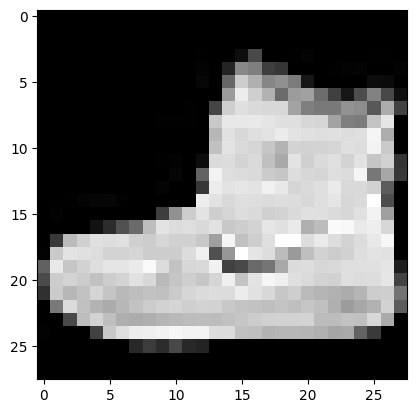

In [ ]:
plt.imshow(image.squeeze(), cmap="gray")

- plt.imshow: 텐서 데이터를 우리가 볼 수 있는 이미지로 화면에 출력합니다. squeeze()를 통해 불필요한 차원을 제거해야 출력이 가능합니다.

In [ ]:
# model_2.state_dict()

### 7.1 Stepping through `nn.Conv2d()`

See the documentation for `nn.Conv2d()` here - https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

In [ ]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image:\n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
torch.manual_seed(42)
# Create a sinlge conv2d layer
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=(3, 3),
                       stride=1,
                       padding=0)

# Pass the data through the convolutional layer
conv_output = conv_layer(test_image.unsqueeze(0))
conv_output.shape

torch.Size([1, 10, 62, 62])

In [ ]:
test_image.unsqueeze(0).shape

torch.Size([1, 3, 64, 64])

### 7.2 Stepping through `nn.MaxPool2d()`

https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html

**참고: MaxPool2d**

`class torch.nn.MaxPool2d(kernel_size, stride=None, padding=0, dilation=1, return_indices=False, ceil_mode=False)`

여러 개의 입력 평면(Input planes)으로 구성된 입력 신호에 **2D 최대 풀링(Max Pooling)**을 적용

---

1. 개요

입력 크기 $(N, C, H, W)$, 출력 크기 $(N, C, H_{out}, W_{out})$, 커널 크기 $(kH, kW)$인 레이어의 출력 값은 다음과 같이 정의됩니다.

$$out(N_i, C_j, h, w) = \max_{m=0, \dots, kH-1} \max_{n=0, \dots, kW-1} input(N_i, C_j, stride[0] \times h + m, stride[1] \times w + n)$$

* **Padding:** `padding`이 0이 아니면, 입력 데이터 양쪽에 지정된 개수만큼 **음의 무한대($-\infty$)**를 채워 넣습니다.
* **Dilation:** 커널 내 요소 사이의 간격을 조절합니다.

2. 주의 사항 (Note)

`ceil_mode=True`일 때, 슬라이딩 윈도우가 왼쪽 패딩이나 입력 범위 내에서 시작한다면 범위를 벗어나더라도 허용됩니다. 단, 오른쪽 패딩 영역에서 시작되는 윈도우는 무시됩니다.

3. 매개변수 (Parameters)

`kernel_size`, `stride`, `padding`, `dilation`은 단일 `int` 또는 두 개의 `int`를 가진 `tuple`로 설정할 수 있습니다.

| 파라미터 | 타입 | 설명 |
| :--- | :--- | :--- |
| **kernel_size** | `int` \| `tuple` | 최댓값을 뽑아낼 윈도우의 크기 |
| **stride** | `int` \| `tuple` | 윈도우의 이동 간격 (기본값: `kernel_size`) |
| **padding** | `int` \| `tuple` | 양옆에 추가할 음의 무한대($-\infty$) 패딩 크기 |
| **dilation** | `int` \| `tuple` | 커널 내 요소 간의 간격을 제어 |
| **return_indices** | `bool` | `True`일 경우 최대값의 인덱스를 함께 반환 (`MaxUnpool2d`에 활용) |
| **ceil_mode** | `bool` | `True`일 경우 출력 크기 계산 시 `floor` 대신 `ceil` 사용 |

---

4. 형태 (Shape)

* **Input:** $(N, C, H_{in}, W_{in})$ 또는 $(C, H_{in}, W_{in})$
* **Output:** $(N, C, H_{out}, W_{out})$ 또는 $(C, H_{out}, W_{out})$

**출력 크기 계산 공식:**
$$H_{out} = \left\lfloor \frac{H

In [ ]:
test_image.shape

torch.Size([3, 64, 64])

In [ ]:
# Print out original image shape without unsqueezed dimension
print(f"Test image original shape: {test_image.shape}")
print(f"Test image with unsqueezed dimension: {test_image.unsqueeze(0).shape}")

# Create a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass data through just the conv_layer
test_image_through_conv = conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv_layer(): {test_image_through_conv.shape}")

# Pass data through the max pool layer
test_image_through_conv_and_max_pool = max_pool_layer(test_image_through_conv)
print(f"Shape after going through conv_layer() and max_pool_layer(): {test_image_through_conv_and_max_pool.shape}")

Test image original shape: torch.Size([3, 64, 64])
Test image with unsqueezed dimension: torch.Size([1, 3, 64, 64])
Shape after going through conv_layer(): torch.Size([1, 10, 62, 62])
Shape after going through conv_layer() and max_pool_layer(): torch.Size([1, 10, 31, 31])


1. 차원 맞추기 (Unsqueeze)

> Original: torch.Size([3, 64, 64]) (색상, 높이, 너비)

> Unsqueezed: torch.Size([1, 3, 64, 64]) (배치 크기, 색상, 높이, 너비)

- PyTorch의 CNN 레이어들은 항상 "몇 개의 데이터를 한꺼번에 처리할 것인가"를 나타내는 Batch 차원을 맨 앞에 요구합니다. 그래서 unsqueeze(0)를 통해 1개짜리 묶음이라는 표시를 해준 것입니다.

- 이유: PyTorch의 컨볼루션(nn.Conv2d)이나 풀링(nn.MaxPool2d) 레이어는 입력으로 (Batch_size, Color_Channels, Height, Width) 4차원 텐서를 기대

- 작동: 일반적인 이미지 (C, H, W)에 .unsqueeze(0)를 사용해 0번째 인덱스에 배치(Batch) 차원을 추가하여 (1, C, H, W)로 만드는 과정

2. Conv 레이어와 MaxPool 레이어 통과

> 채널: 3개(RGB)였던 채널이 10개의 필터를 거치며 10개가 되었습니다.

> 크기: $64 \times 64$ 이미지가 컨볼루션 연산(커널 크기 등에 따라 달라짐)을 거치며 $62 \times 62$로 약간 줄어들었습니다.

- Conv 레이어: 이미지에서 특징(Feature)을 추출하며 채널 수나 크기를 변화시킵니다.

- MaxPool 레이어: kernel_size=2를 적용하면 가로세로 크기가 각각 절반으로 줄어듭니다. 특징 맵(Feature map)의 중요한 정보만 남기고 데이터 크기를 압축하는 역할을 합니다.

In [ ]:
torch.manual_seed(42)
# Create a random tesnor with a similar number of dimensions to our images
random_tensor = torch.randn(size=(1, 1, 2, 2))
print(f"\nRandom tensor:\n{random_tensor}")
print(f"Random tensor shape: {random_tensor.shape}")

# Create a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size=2)

# Pass the random tensor through the max pool layer
max_pool_tensor = max_pool_layer(random_tensor)
print(f"\nMax pool tensor:\n {max_pool_tensor}")
print(f"Max pool tensor shape: {max_pool_tensor.shape}")


Random tensor:
tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
Random tensor shape: torch.Size([1, 1, 2, 2])

Max pool tensor:
 tensor([[[[0.3367]]]])
Max pool tensor shape: torch.Size([1, 1, 1, 1])


3. 수치로 확인하는 MaxPool2d 원리

> kernel_size=2를 사용했기 때문에, 가로와 세로가 각각 절반으로 줄어들었습니다 ($62 \div 2 = 31$).중요한 점은 채널 수(10개)는 그대로 유지된다는 것입니다. 풀링은 이미지의 해상도만 줄일 뿐 특징의 종류(채널)를 합치지는 않습니다.

- 입력: $2 \times 2$ 크기의 텐서를 만듭니다.

  예: [[0.1, 0.5], [0.3, 0.2]]

- 연산: kernel_size=2이므로 전체 $2 \times 2$ 영역을 한 번에 봅니다.

- 결과: 그 영역에 있는 값 중 가장 큰 값 하나만 남깁니다.
  결과: [[0.5]] (차원은 $1 \times 1$이 됨)

<요약>

MaxPool2d는 정해진 크기(kernel_size) 안에서 가장 큰 값만 뽑아냅니다.

이 과정에서 이미지의 해상도(가로, 세로)는 줄어들지만, 가장 강한 특징값은 보존됩니다.

결과적으로 연산량을 줄이고 모델이 사소한 변화에 덜 민감하게(Robust) 만듭니다.

### [참고] CNN Explainer
> CNN Max Pooling의 이해

1. Max Pooling의 핵심 동작
* **최댓값 추출:** 커널(Kernel) 영역 내의 입력값 중 **가장 큰 값**만을 선택하여 출력합니다.
* **공간 압축:** 4개의 숫자(2x2 영역)에서 최대치 1개만 남기는 방식으로 데이터를 압축합니다.
    * 예: 입력 $60 \times 60$ → 출력 $30 \times 30$ (크기가 절반으로 감소)

2. 딥러닝 관점에서의 목적: "지능은 곧 압축이다"
* **기능 벡터화:** CNN은 입력 데이터에서 가장 적합한 특징(Feature)을 파악한 뒤, 이를 핵심 정보만 담긴 **기능 벡터**로 압축합니다.
* **차원 축소:** 고차원의 텐서 공간에서 **더 작은 벡터 공간**으로 이동하여 데이터의 패턴을 구성합니다.
* **미래 예측:** 압축된 작은 공간은 원본 데이터의 정수를 담고 있으며, 이를 통해 새로운 데이터를 예측할 수 있는 힘을 얻습니다.

3. 주요 특징 및 이점
* **가장 중요한 패턴 유지:** 특정 섹션에서 최대값만 취하더라도 대상의 윤곽(예: 자동차의 형태)과 같은 **가장 중요한 특징**은 보존됩니다.
* **잠재적 특징 추출:** 특정 영역의 최대치를 활용함으로써 해당 섹션에서 가장 지배적인 기능을 얻을 수 있습니다.
* **유연한 설정:** 사용자 정의에 따라 `kernel_size`를 4x4 등으로 늘려 압축 강도를 조절할 수 있습니다.



---
> **요약:** Max Pooling은 단순히 숫자를 줄이는 것이 아니라, 데이터에서 **가장 중요한 정보(Strong Signal)만 남기고 나머지는 걸러내는 "지능적 압축"** 과정입니다.

### 7.3 Setup a loss function and optimizer for `model_2`

> Mode 2: Using a Trick to Find the Input and Output Shapes of Each of Our Layers

In [ ]:
# Setup loss function/eval metrics/optimizer
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

<학습 설정 (Loss, Metrics, Optimizer)>

모델이 얼마나 잘하고 있는지 측정하고, 틀린 부분을 어떻게 고칠지 결정하는 '학습 규칙'을 정의하는 단계입니다.

1. 평가 지표 (Evaluation Metrics)
* **`accuracy_fn`**: 모델의 예측이 실제 정답과 얼마나 일치하는지 **정확도(%)**를 계산합니다.
    * *외부 파일(`helper_functions.py`)에서 가져온 사용자 정의 함수입니다.*

2. 손실 함수 (Loss Function)
* **`nn.CrossEntropyLoss()`**: 모델이 예측한 확률 분포와 실제 정답 사이의 거리를 측정합니다.
    * **역할:** 모델이 틀린 정답에 확신을 가질수록 손실 값을 매우 크게 주어, 모델이 올바른 방향으로 학습하도록 유도합니다.
    * **용도:** 다중 클래스 분류(Multi-class Classification) 문제의 표준 손실 함수입니다.

3. 옵티마이저 (Optimizer)
* **`torch.optim.SGD`**: **확률적 경사 하강법(Stochastic Gradient Descent)**을 사용하여 가중치를 업데이트합니다.
    * **`params=model_2.parameters()`**: `model_2`가 가진 모든 학습 가능한 변수(가중치와 편향)를 최적화 대상으로 지정합니다.
    * **`lr=0.1` (Learning Rate)**: 모델이 한 번에 얼마나 큰 보폭으로 학습할지 결정합니다. 너무 크면 최적점을 지나치고, 너무 작으면 학습이 너무 느려집니다.

### 7.4 Training and testing `model_2` using our training and test functions

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-------")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Train loss: 0.59334 | Train acc: 78.43%
Test loss: 0.39030 | Test acc: 86.03%

Epoch: 1
-------
Train loss: 0.36332 | Train acc: 86.91%
Test loss: 0.35219 | Test acc: 86.96%

Epoch: 2
-------
Train loss: 0.32484 | Train acc: 88.32%
Test loss: 0.32357 | Test acc: 87.86%

Train time on cuda: 39.229 seconds


<모델 학습 및 평가 루프 (Training Loop)>

이 코드는 설정한 에포크(Epoch)만큼 데이터를 반복해서 읽으며 모델을 학습시키고, 동시에 테스트 데이터로 성능을 확인합니다.

1. 재현성을 위한 시드(Seed) 설정
* **`torch.manual_seed(42)` / `torch.cuda.manual_seed(42)`**: 무작위성을 제어하여 코드를 다시 실행해도 똑같은 학습 결과가 나오도록 고정합니다.

2. 학습 시간 측정
* **`timer()`**: 학습이 시작되는 시점과 끝나는 시점을 기록하여, 총 얼마만큼의 시간이 소요되었는지 계산합니다. (모델의 효율성을 판단하는 지표가 됩니다.)

3. 에포크(Epoch) 반복 및 단계별 수행
* **`epochs = 3`**: 전체 데이터셋을 총 3번 훑으며 학습합니다.
* **`tqdm`**: 학습 진행 상황을 프로그레스 바(Progress Bar) 형태로 시각화해줍니다.

① 학습 단계 (`train_step`)
* 모델이 **훈련 데이터(`train_dataloader`)**를 보고 가중치를 업데이트합니다.
* `loss_fn`으로 틀린 정도를 계산하고, `optimizer`가 모델을 수정합니다.

② 테스트 단계 (`test_step`)
* 학습되지 않은 **검증 데이터(`test_dataloader`)**를 통해 모델의 실제 실력을 확인합니다.
* 이때는 가중치를 업데이트하지 않고 오직 점수(`accuracy_fn`, `loss_fn`)만 측정합니다.



### 4. 최종 결과 출력
* **`print_train_time`**: 시작 시간과 종료 시간을 비교하여 총 학습 시간을 `device`(CPU 또는 GPU) 정보와 함께 출력합니다.

In [ ]:
# Get model_2 results
model_2_results = eval_model(
     model=model_2,
     data_loader=test_dataloader,
     loss_fn=loss_fn,
     accuracy_fn=accuracy_fn,
     device=device
)

model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.3235677480697632,
 'model_acc': 87.8594249201278}

## 8. Compare model results and training time (127)

In [ ]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.476639,83.426518
1,FashionMNISTModelV1,0.685001,75.019968
2,FashionMNISTModelV2,0.323568,87.859425


In [ ]:
# Add training time to results comparison
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.476639,83.426518,27.931088
1,FashionMNISTModelV1,0.685001,75.019968,34.653180
2,FashionMNISTModelV2,0.323568,87.859425,39.229174


모델별 성능 비교 요약
- Model V0 (Baseline): 선형 레이어만 썼는데 정확도 83.43% 나왔음.

- Model V1 (Non-linear): 비선형성(ReLU)을 추가하고 GPU까지 썼는데 정확도가 75.02%로 오히려 떨어졌음. 레이어만 더 넣는다고 무조건 좋아지는 게 아님.

- Model V2 (CNN): TinyVGG 구조를 복제한 CNN 모델임. 정확도 87.86%로 압도적 1등 찍었음.

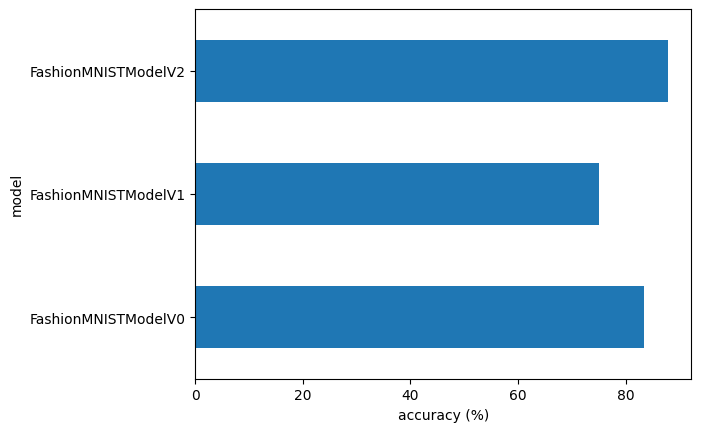

In [ ]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model");

<주요 인사이트 및 해석>

- 지능은 곧 압축임: CNN이 고차원의 이미지 데이터를 핵심 특징 벡터로 잘 압축해서 성능이 잘 나온 것으로 보임.

- 성능과 속도의 밀당 (Trade-off): CNN이 정확도는 제일 높지만 훈련 시간(39.23초)은 가장 오래 걸렸음. 실전에서는 5%의 정확도를 위해 시간을 더 쓸지, 아니면 조금 덜 정확해도 10배 빠른 모델을 쓸지 결정해야 함.

- 하드웨어별 차이 존재: 훈련 시간은 쓰는 GPU(Tesla P100 등)나 코랩 환경에 따라 달라짐. 숫자가 나랑 똑같이 안 나와도 너무 쫄 필요 없다고 대본에서 말해줌.

- 재현성 체크: 결과가 너무 이상하게 다르면 무작위 시드(random_seed) 설정이 제대로 됐는지 다시 확인해야 함.

## 9. Make and evaluate random predictions with best model

In [ ]:
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device = device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # Prepare the sample (add a batch dimension and pass to target device)
      sample = torch.unsqueeze(sample, dim=0).to(device)

      # Forward pass (model outputs raw logits)
      pred_logit = model(sample)

      # Get prediction probability (logit -> prediction probability)
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)

      # Get pred_prob off the GPU for further calculations
      pred_probs.append(pred_prob.cpu())

  # Stack the pred_probs to turn list into a tensor
  return torch.stack(pred_probs)

In [ ]:
import random
# random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

# View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sneaker')

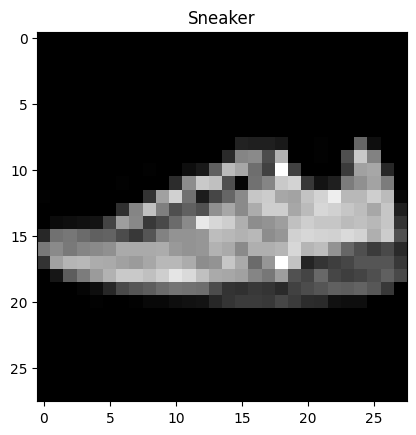

In [ ]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [ ]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)

# View first two prediction probabilities
pred_probs[:2]

tensor([[3.1196e-07, 3.6615e-07, 9.1140e-07, 1.7568e-06, 8.6442e-07, 4.0063e-04,
         1.2530e-07, 9.9944e-01, 3.0873e-05, 1.2806e-04],
        [2.2930e-03, 6.9774e-07, 2.1407e-04, 1.4821e-07, 3.0780e-05, 2.6237e-05,
         6.6426e-04, 6.9873e-06, 9.9669e-01, 7.6665e-05]])

In [ ]:
# Convert prediction probabilities to labels
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([7, 8, 3, 0, 0, 7, 7, 6, 9])

In [ ]:
test_labels

[7, 8, 2, 0, 0, 5, 7, 6, 9]

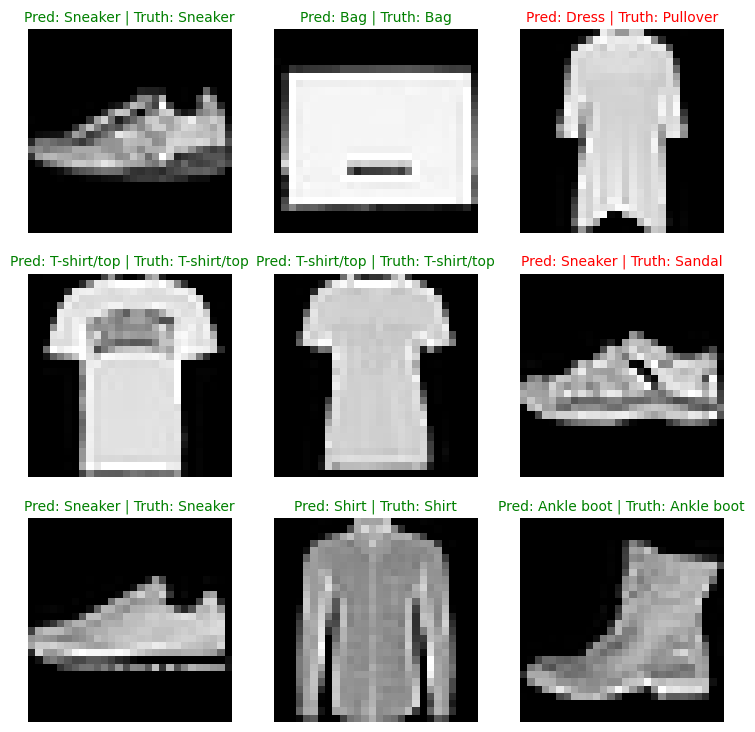

In [ ]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction (in text form, e.g "Sandal")
  pred_label = class_names[pred_classes[i]]

  # Get the truth label (in text form)
  truth_label = class_names[test_labels[i]]

  # Create a title for the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality between pred and truth and change color of title text
  if pred_label == truth_label:
    plt.title(title_text, fontsize=10, c="g") # green text if prediction same as truth
  else:
    plt.title(title_text, fontsize=10, c="r")

  plt.axis(False);

## 10. Making a confusion matrix for further prediction evaluation

A confusion matrix is a fantastic way of evaluating your classification models visually: https://www.learnpytorch.io/02_pytorch_classification/#9-more-classification-evaluation-metrics

1. Make predictions with our trained model on the test dataset
2. Make a confusion matrix `torchmetrics.ConfusionMatrix` - https://torchmetrics.readthedocs.io/en/stable/classification/confusion_matrix.html
3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()` - http://rasbt.github.io/mlxtend/user_guide/plotting/plot_confusion_matrix/

In [ ]:
# Import tqdm.auto
from tqdm.auto import tqdm


# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions..."):
    # Send the data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> prediction labels
    y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
    # Put prediction on CPU for evaluation
    y_preds.append(y_pred.cpu())

# Concatenate list of predictions into a tensor
# print(y_preds)
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 8])

In [ ]:
len(y_pred_tensor)

10000

In [ ]:
# See if required packages are installed and if not, install them...
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1] >= 19, "mlxtend version should be 0.19.0 or higher")
except:
  !pip install torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.24.0
mlxtend version: 0.24.0


In [ ]:
import mlxtend
print(mlxtend.__version__)

0.24.0


In [ ]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
y_pred_tensor[:10]

tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [ ]:
test_data.targets

tensor([9, 2, 1,  ..., 8, 1, 5])

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with numpy
    class_names=class_names,
    figsize=(10, 7)
)

TypeError: ConfusionMatrix.__new__() missing 1 required positional argument: 'task'

## 11. Save and load best performing model

In [ ]:
from pathlib import Path

# Create model dictory path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,
                 exist_ok=True)

# Create model save
MODEL_NAME = "03_pytorch_computer_vision_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_2.state_dict(),
           f=MODEL_SAVE_PATH)

In [ ]:
image_shape = [1, 28, 28]

In [ ]:
# Create a new instance
torch.manual_seed(42)

loaded_model_2 = FashionMNISTModelV2(input_shape=1,
                                     hidden_units=10,
                                     output_shape=len(class_names))

# Load in the save state_dict()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# Send the model to the target device
loaded_model_2.to(device)

In [ ]:
# Evaluate loaded model
torch.manual_seed(42)

loaded_model_2_results = eval_model(
    model=loaded_model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

loaded_model_2_results

In [ ]:
model_2_results

In [ ]:
# Check if model results are close to each other
torch.isclose(torch.tensor(model_2_results["model_loss"]),
              torch.tensor(loaded_model_2_results["model_loss"]),
              atol=1e-02)

## Exercises

* See here for exercises and extra-curriculum: https://www.learnpytorch.io/03_pytorch_computer_vision/#exercises
